In [17]:
import os
import h5py
import numpy as np
import json
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display, clear_output
from sklearn.metrics import classification_report, confusion_matrix

%matplotlib inline
sns.set_style('whitegrid')

In [18]:
from keras import optimizers
from keras.applications.vgg16 import VGG16
from keras.models import Sequential, load_model, Model
from keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D, Activation, Dropout, Flatten, Dense, Input
from keras.regularizers import l2, l1
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.image import  array_to_img, img_to_array, load_img
from keras.callbacks import ModelCheckpoint, History
from keras import backend as K
from tensorflow.keras.utils import get_file
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [19]:
def plot_metrics(hist, stop=10):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
                            
    axes = axes.flatten()

    axes[0].plot(range(stop), hist['accuracy'], label='Training', color='#FF533D')
    axes[0].plot(range(stop), hist['val_accuracy'], label='Validation', color='#03507E')
    axes[0].set_title('Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='lower right')
                             
    axes[1].plot(range(stop), hist['loss'], label='Training', color='#FF533D')
    axes[1].plot(range(stop), hist['val_loss'], label='Validation', color='#03507E')
    axes[1].set_title('Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='upper right')
                             
    plt.tight_layout();
    
    print("Best Model:") 
    print_best_model_results(hist)

In [20]:
def plot_acc_metrics(hist1, hist2, stop=10):
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(4.25,6))
                            
    axes = axes.flatten()
    
    axes[0].plot(range(stop), hist1['accuracy'], label='Training', color='#FF533D')
    axes[0].plot(range(stop), hist1['val_accuracy'], label='Validation', color='#03507E')
    axes[0].set_title('Training')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='lower right')
                             
    axes[1].plot(range(stop), hist2['accuracy'], label='Training', color='#FF533D')
    axes[1].plot(range(stop), hist2['val_accuracy'], label='Validation', color='#03507E')
    axes[1].set_title('Fine-tuning')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='lower right')
                             
    plt.tight_layout();

In [21]:
def print_best_model_results(model_hist):
    best_epoch = np.argmax(model_hist['val_accuracy'])
    print('epoch:', best_epoch+1, \
    ', val_accuracy:', model_hist['val_accuracy'][best_epoch], \
    ', val_loss:', model_hist['val_loss'][best_epoch])

In [22]:
def save_bottleneck_features():
    datagen = ImageDataGenerator(rescale=1./255)
    
    model = VGG16(include_top=False, weights='imagenet')
    
    generator = datagen.flow_from_directory(train_data_dir, target_size=(img_width, img_height), batch_size=batch_size, class_mode=None, shuffle=False)
    bottleneck_features_train = model.predict(generator, nb_train_samples // batch_size)
    np.save(location+'/bottleneck_features_train.npy', bottleneck_features_train)
    
    generator = datagen.flow_from_directory(validation_data_dir, target_size=(img_width, img_height), batch_size=batch_size, class_mode=None, shuffle=False)
    bottleneck_features_validation = model.predict(generator, nb_validation_samples // batch_size)
    np.save(location+'/bottleneck_features_validation.npy', bottleneck_features_validation)

def train_top_model():
    train_data = np.load(location+'/bottleneck_features_train.npy')
    train_labels = np.array([0] * (nb_train_samples // 2) + [1] * (nb_train_samples // 2))
    
    validation_data = np.load(location+'/bottleneck_features_validation.npy')
    validation_labels = np.array([0] * (nb_validation_samples // 2) + [1] * (nb_validation_samples // 2))
    
    model = Sequential()
    model.add(Flatten(input_shape=train_data.shape[1:]))
    model.add(Dense(256,activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
    
    checkpoint = ModelCheckpoint(filepath=top_model_weights_path, monitor='val_acc', verbose=1, save_best_only=True, save_weights_only=False, mode='auto')
    
    fit = model.fit_generator(train_data, train_labels, epochs=epochs, batch_size=batch_size,validation_data=(validation_data,validation_labels), callbacks=[checkpoint])
    
    with open(location+'/top_history.txt', 'w') as f:
        json.dump(fit.history, f) 
        
    return model, fit.history

In [23]:

def train_top_model():
    # Load bottleneck features
    train_data = np.load(location + '/bottleneck_features_train.npy')
    train_labels = np.array([0] * (nb_train_samples // 2) + [1] * (nb_train_samples // 2))
    
    validation_data = np.load(location + '/bottleneck_features_validation.npy')
    validation_labels = np.array([0] * (nb_validation_samples // 2) + [1] * (nb_validation_samples // 2))
    
    # Define the top model
    model = Sequential()
    model.add(Flatten(input_shape=train_data.shape[1:]))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    model.compile(optimizer='rmsprop', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    
    # Define ModelCheckpoint to save the best model
    checkpoint = ModelCheckpoint(filepath=top_model_weights_path, 
                                 monitor='val_accuracy',  # Use 'val_accuracy' instead of 'val_acc'
                                 verbose=1, 
                                 save_best_only=True, 
                                 save_weights_only=True,  # Save the full model
                                 mode='auto')
    
    # Fit the model using `fit()` instead of `fit_generator`
    fit = model.fit(train_data, 
                    train_labels, 
                    epochs=epochs, 
                    batch_size=batch_size, 
                    validation_data=(validation_data, validation_labels), 
                    callbacks=[checkpoint])
    
    # Save training history
    with open(location + '/top_history.txt', 'w') as f:
        json.dump(fit.history, f)
    
    # Save the entire model manually
    try:
        model.save(location + '/top_model_final.h5')
        print("Model saved successfully.")
    except Exception as e:
        print(f"Error saving the model: {e}")
    
    return model, fit.history


def finetune_binary_model():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256,256,3))
    print("Model loaded.")
    
    top_model = Sequential()
    top_model.add(Flatten(input_shape=base_model.output_shape[1:]))
    top_model.add(Dense(256, activation='relu'))
    top_model.add(Dropout(0.5))
    top_model.add(Dense(1, activation='sigmoid'))
    
    top_model.load_weights(top_model_weights_path)
    
    model = Model(inputs=base_model.input, outputs=top_model(base_model.output))
    
    for layer in model.layers[:25]:
        layer.trainable = False
    
    model.compile(loss='binary_crossentropy', optimizer=optimizers.SGD(lr=1e-4, momentum=0.9), metrics=['accuracy'])
    
    train_datagen = ImageDataGenerator(rescale = 1./255, zoom_range=0.2, shear_range=0.2, horizontal_flip=True)
    
    test_datagen = ImageDataGenerator(rescale=1./255)
    
    train_generator = train_datagen.flow_from_directory(train_data_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='binary')
    
    validation_generator = test_datagen.flow_from_directory(validation_data_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='binary')
    
    checkpoint = ModelCheckpoint(filepath=fine_tuned_model_path, monitor='val_accuracy', verbose=1, save_best_only=True, save_weights_only=False, mode='auto')
    
    fit = model.fit_generator(train_generator, steps_per_epoch=nb_train_samples//batch_size, epochs=epochs, validation_data=validation_generator, validation_steps=nb_validation_samples//batch_size, verbose=1, callbacks=[checkpoint])
    
    with open(location+'/ft_history.txt', 'w') as a:
        json.dump(fit.history, a)
        
    return model, fit.history  

In [24]:
def finetune_binary_model():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
    print("Base model loaded.")
    
    # Define the top model
    top_model = Sequential()
    top_model.add(Flatten(input_shape=base_model.output_shape[1:]))
    top_model.add(Dense(256, activation='relu'))
    top_model.add(Dropout(0.5))
    top_model.add(Dense(1, activation='sigmoid'))
    
    # Load weights for the top model
    top_model.load_weights(top_model_weights_path)
    
    # Combine base model and top model
    model = Model(inputs=base_model.input, outputs=top_model(base_model.output))
    
    # Freeze the initial layers
    for layer in model.layers[:25]:
        layer.trainable = False
    
    # Compile the model
    model.compile(loss='binary_crossentropy', 
                  optimizer=optimizers.SGD(learning_rate=1e-4, momentum=0.9), 
                  metrics=['accuracy'])
    
    # Data augmentation for training
    train_datagen = ImageDataGenerator(rescale=1./255, 
                                       zoom_range=0.2, 
                                       shear_range=0.2, 
                                       horizontal_flip=True)
    
    # Data preparation for validation
    test_datagen = ImageDataGenerator(rescale=1./255)
    
    # Data generators
    train_generator = train_datagen.flow_from_directory(train_data_dir, 
                                                        target_size=(img_height, img_width), 
                                                        batch_size=batch_size, 
                                                        class_mode='binary')
    
    validation_generator = test_datagen.flow_from_directory(validation_data_dir, 
                                                            target_size=(img_height, img_width), 
                                                            batch_size=batch_size, 
                                                            class_mode='binary')
    
    # ModelCheckpoint callback for saving the best model
    checkpoint = ModelCheckpoint(filepath=fine_tuned_model_path, 
                                 monitor='val_accuracy', 
                                 verbose=1, 
                                 save_best_only=True, 
                                 save_weights_only=False, 
                                 mode='auto')
    
    # Use fit() instead of fit_generator
    fit = model.fit(train_generator, 
                    steps_per_epoch=nb_train_samples // batch_size, 
                    epochs=epochs, 
                    validation_data=validation_generator, 
                    validation_steps=nb_validation_samples // batch_size, 
                    verbose=1, 
                    callbacks=[checkpoint])
    
    # Save the training history
    with open(location + '/ft_history.txt', 'w') as a:
        json.dump(fit.history, a)
    
    # Save the entire model manually if needed
    try:
        model.save(location + '/fine_tuned_final_model.h5')
        print("Model saved successfully.")
    except Exception as e:
        print(f"Error saving the model: {e}")
    
    return model, fit.history


In [25]:
def evaluate_binary_model(model, directory, labels):
    datagen = ImageDataGenerator(rescale=1./255)
    
    generator = datagen.flow_from_directory(directory, target_size=(img_height,img_width), batch_size=batch_size, class_mode='binary', shuffle=False)
    
    predictions = model.predict(generator, len(labels))
    
    pred_labels = [0 if i<0.5 else 1 for i in predictions]
    
    print('')
    print(classification_report(validation_labels, pred_labels))
    print('')
    cm = confusion_matrix(validation_labels, pred_labels)
    return cm

In [29]:
location = r'C:\Users\pbans\Desktop\CD_2\data2'
top_model_weights_path = location+'/top_model_weights.weights.h5'
fine_tuned_model_path = location+'/ft_model.keras'

train_data_dir = location+'/training'
validation_data_dir = location+'/validation'
train_samples = [len(os.listdir(train_data_dir+'/'+i)) for i in sorted(os.listdir(train_data_dir))]
nb_train_samples = 1840
validation_samples = [len(os.listdir(validation_data_dir+'/'+i)) for i in sorted(os.listdir(validation_data_dir))]
nb_validation_samples = 460

img_width, img_height = 256,256
epochs = 10
batch_size = 16

In [27]:
save_bottleneck_features()

Found 1840 images belonging to 2 classes.


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


115/115 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step
Found 460 images belonging to 2 classes.
29/29 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step


In [30]:
d2_model1, d2_history1 = train_top_model()

Epoch 1/10
114/115 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6739 - loss: 3.3719
Epoch 1: val_accuracy improved from -inf to 0.76739, saving model to C:\Users\pbans\Desktop\CD_2\data2/top_model_weights.weights.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6752 - loss: 3.3387 - val_accuracy: 0.7674 - val_loss: 0.5205
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8140 - loss: 0.4470
Epoch 2: val_accuracy did not improve from 0.76739
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8141 - loss: 0.4468 - val_accuracy: 0.7109 - val_loss: 0.9068
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8690 - loss: 0.3515
Epoch 3: val_accuracy improved from 0.76739 to 0.90217, saving model to C:\Users\pbans\Desktop\CD_2\data2/top_model_weights.weights.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8689 - loss: 0.3515 - val_accuracy: 0.9022 - val_loss: 0.2244
Epoch 4/10
114/115 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.

Model saved successfully.


Best Model:
epoch: 10 , val_accuracy: 0.9304347634315491 , val_loss: 0.2911680340766907


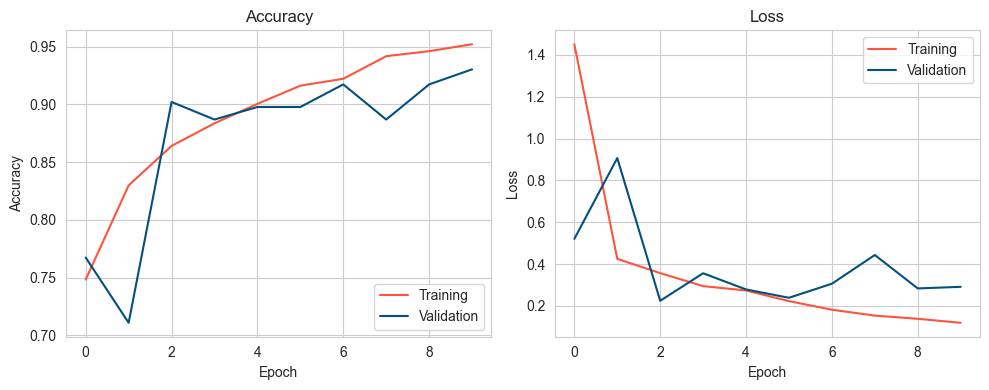

In [31]:
plot_metrics(d2_history1)


In [32]:
ft_model, ft_history = finetune_binary_model()

Base model loaded.
Found 1840 images belonging to 2 classes.
Found 460 images belonging to 2 classes.
Epoch 1/10


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9145 - loss: 0.2910
Epoch 1: val_accuracy improved from -inf to 0.93080, saving model to C:\Users\pbans\Desktop\CD_2\data2/ft_model.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 288s 3s/step - accuracy: 0.9144 - loss: 0.2911 - val_accuracy: 0.9308 - val_loss: 0.2968
Epoch 2/10


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)



Epoch 2: val_accuracy did not improve from 0.93080
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.9167 - val_loss: 0.0827
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8874 - loss: 0.3969
Epoch 3: val_accuracy did not improve from 0.93080
115/115 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.8875 - loss: 0.3962 - val_accuracy: 0.9286 - val_loss: 0.2974
Epoch 4/10

Epoch 4: val_accuracy improved from 0.93080 to 1.00000, saving model to C:\Users\pbans\Desktop\CD_2\data2/ft_model.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0597
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8965 - loss: 0.3039
Epoch 5: val_accuracy did not improve from 1.00000
115/115 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.8965 - loss: 0.3040 - val_accuracy: 0.9286 - val_loss: 0.2987
Epoch 6/10

Epoch 6: val_accuracy did not improve from 1

Model saved successfully.


In [33]:

ft_model = load_model(location+'/ft_model.keras')

In [41]:
with open(r'C:\Users\pbans\Desktop\CD_2\data2\top_history.txt') as f:    
    top_history = json.load(f)


In [42]:
with open(r'C:\Users\pbans\Desktop\CD_2\data2\ft_history.txt') as f:    
    ft_history = json.load(f)

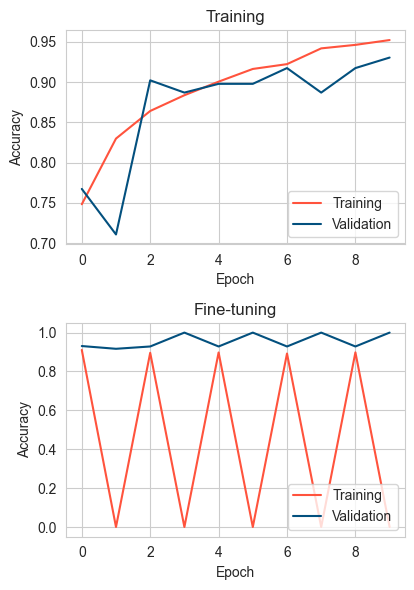

In [43]:
plot_acc_metrics(top_history, ft_history)

Best Model:
epoch: 4 , val_accuracy: 1.0 , val_loss: 0.05973421409726143


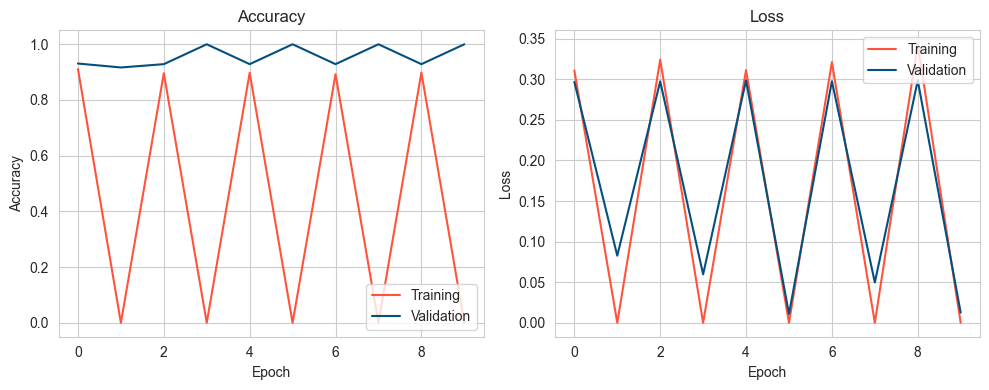

In [55]:
# WINNER
plot_metrics(ft_history) # sgd with lr = 0.0001, sigmoid, with l2 = 0.001

In [44]:
validation_labels = np.array([0] * (nb_validation_samples // 2) + [1] * (nb_validation_samples // 2))


In [45]:
cm = evaluate_binary_model(ft_model, validation_data_dir, validation_labels)



Found 460 images belonging to 2 classes.


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 971ms/step

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       230
           1       0.93      0.93      0.93       230

    accuracy                           0.93       460
   macro avg       0.93      0.93      0.93       460
weighted avg       0.93      0.93      0.93       460




In [52]:
heatmap_labels = ['00-damage', '01-whole']

<Axes: >

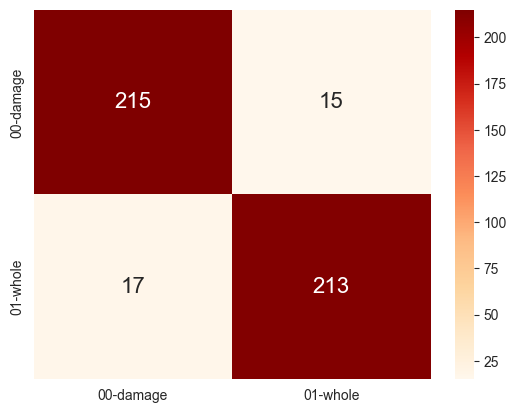

In [53]:
sns.heatmap(cm, annot=True, annot_kws={"size":16}, fmt='g', cmap='OrRd', xticklabels= heatmap_labels, yticklabels= heatmap_labels)


<Axes: >

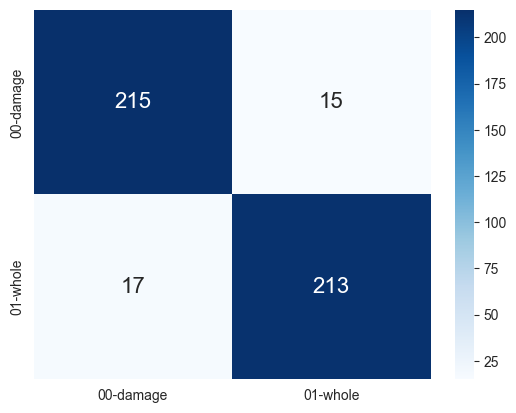

In [54]:
sns.heatmap(cm, annot=True, annot_kws={"size":16}, fmt='g', cmap='Blues', xticklabels=heatmap_labels, yticklabels=heatmap_labels)


In [42]:
def pipe2(image_path, model):
    urllib.request.urlretrieve(image_path, 'save.jpg')
    img = load_img('save.jpg', target_size=(256,256))
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)/255
    pred = model.predict(x)
    print("Validating that damage exists....")
    print(pred)
    if(pred[0][0]<=0.5):
        print("Validation complete - proceed to location and severity determination")
    else:
        print ("Are you sure that your car is damaged? Please submit another picture of the damage.")
        print ("Hint: Try zooming in/out, using a different angle or different lighting")      

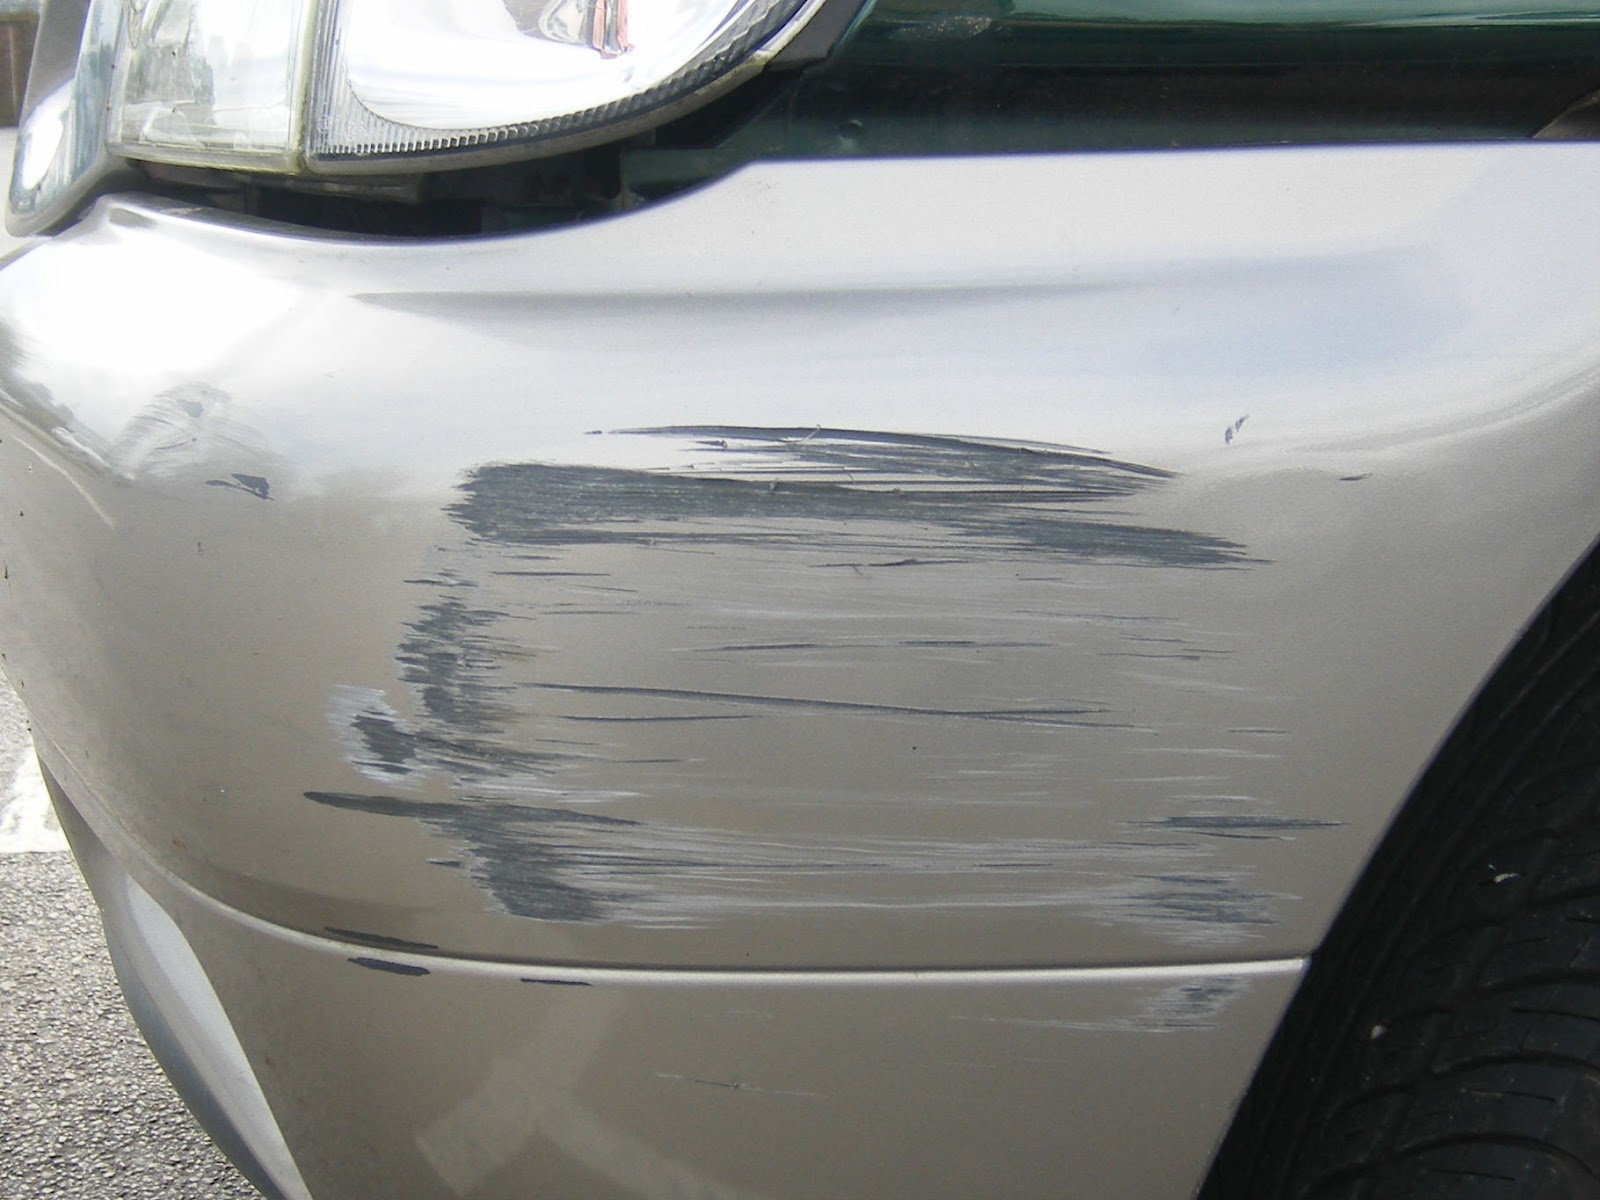

In [ ]:
Image('http://3.bp.blogspot.com/-PrRY9XxCqYQ/UDNutnMI7LI/AAAAAAAABdw/UGygghh-hRA/s1600/Bumper+scuff.JPG')

In [49]:
pipe2('http://3.bp.blogspot.com/-PrRY9XxCqYQ/UDNutnMI7LI/AAAAAAAABdw/UGygghh-hRA/s1600/Bumper+scuff.JPG', ft_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Validating that damage exists....
[[0.00025494]]
Validation complete - proceed to location and severity determination


## trying our model on ramndom images

In [56]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the trained model
model = load_model(r'C:\Users\pbans\OneDrive\Desktop\CD2\data2\ft_model.keras')

# Load and preprocess the image
img_path = r"C:\Users\pbans\OneDrive\Desktop\download.jpg" # Path to your test image
img = image.load_img(img_path, target_size=(256, 256))  # Resize the image
img_array = image.img_to_array(img)  # Convert to an array
img_array = img_array / 255.0  # Normalize if the model was trained on normalized images
img_array = np.expand_dims(img_array, axis=0)  # Add a batch dimension

# Make a prediction
predictions = model.predict(img_array)

# For binary classification (threshold at 0.5)
predicted_class = (predictions > 0.5).astype(int)

# Output the result
print(f"Predicted Class: {predicted_class}")

# If you have class labels, you can map the predicted class index to the label
class_labels = ['00-damage', '01-whole']
predicted_label = class_labels[predicted_class[0][0]]  # Access the class label
print(f"Predicted Label: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
Predicted Class: [[0]]
Predicted Label: 00-damage


In [56]:
def get_edge_cases(model, directory, exp_result):
    img_list = os.listdir(directory)
    edge_list = []
    for name in img_list:
        img = load_img(directory+name, target_size=(256, 256)) # this is a PIL image 
        x = img_to_array(img) # this is a Numpy array with shape (3, 256, 256)
        x = x.reshape((1,) + x.shape)/255 # this is a Numpy array with shape (1, 3, 256, 256)
        pred_prob = model.predict(x)
        if pred_prob <=0.5:
            pred = 0
        else:
            pred = 1
        if pred != exp_result:
            edge_list.append(name)
    return edge_list

In [57]:
evaluate_binary_model(ft_model, validation_data_dir, validation_labels)
# TP = 221, TN = 194, FP = 36, FN = 9
# 9 were predicted to be damaged but were actually whole
# 36 were predicted to be whole but were actually damaged

Found 460 images belonging to 2 classes.


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 984ms/step

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       230
           1       0.93      0.93      0.93       230

    accuracy                           0.93       460
   macro avg       0.93      0.93      0.93       460
weighted avg       0.93      0.93      0.93       460




array([[215,  15],
       [ 17, 213]], dtype=int64)